## Exploratory Data Analysis


In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# Now import your modules
import pandas as pd
from src.config import DATABASE_URL
from sqlalchemy import create_engine

In [4]:
engine = create_engine(DATABASE_URL)
df = pd.read_sql("SELECT * FROM smard_market_data ORDER BY timestamp", engine)
df.head()

,timestamp,gen_nuclear,gen_lignite,gen_offshore_wind,gen_hydro,gen_other_conv,gen_other_renew,gen_biomass,gen_onshore_wind,gen_solar,...,cons_pumped_storage,price_de_lu,price_neighbors,price_at,proj_offshore,proj_onshore,proj_solar,proj_other,proj_wind_solar,proj_total
0,2020-05-03 22:00:00+00:00,1625.25,1788.00,132.00,492.25,386.75,49.75,1124.00,404.25,0.0,...,131.00,22.20,17.42,22.20,131.75,547.50,0.0,5800.38,679.25,6479.63
1,2020-05-03 22:15:00+00:00,1624.25,1814.00,135.00,442.25,385.00,49.75,1118.25,415.75,0.0,...,182.25,22.20,NaN,22.20,128.00,549.00,0.0,5802.63,677.00,6479.63
2,2020-05-03 22:30:00+00:00,1603.75,1817.25,140.50,428.50,383.75,49.75,1117.75,403.25,0.0,...,353.00,22.20,NaN,22.20,124.25,550.50,0.0,5804.88,674.75,6479.63
3,2020-05-03 22:45:00+00:00,1602.75,1812.25,148.25,445.50,384.25,49.75,1117.25,396.50,0.0,...,478.50,22.20,NaN,22.20,121.00,552.25,0.0,5806.38,673.25,6479.63
4,2020-05-03 23:00:00+00:00,1608.00,1781.00,145.25,463.00,385.25,49.75,1114.25,399.50,0.0,...,515.50,20.46,16.18,20.46,118.50,554.25,0.0,6041.08,672.75,6713.83


### 1. Missing Values & Imputation Strategy
We will analyze missing values per column and suggest appropriate imputation strategies based on data type and business context.

In [5]:
# Show missing values per column and data types
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': df.isnull().mean() * 100,
    'dtype': df.dtypes
})
missing_summary = missing_summary.sort_values('missing_pct', ascending=False)
display(missing_summary)

,missing_count,missing_pct,dtype
price_neighbors,131544,75.000000,float64
gen_nuclear,44202,25.201834,float64
cons_residual,3,0.001710,float64
timestamp,0,0.000000,"datetime64[us, UTC]"
gen_lignite,0,0.000000,float64
gen_other_conv,0,0.000000,float64
gen_other_renew,0,0.000000,float64
gen_offshore_wind,0,0.000000,float64
gen_hydro,0,0.000000,float64
gen_onshore_wind,0,0.000000,float64


### 2. Seasonality Analysis (Daily, Weekly, Yearly)
We will explore seasonality patterns in load, generation, and price data using time series decomposition and visualizations.

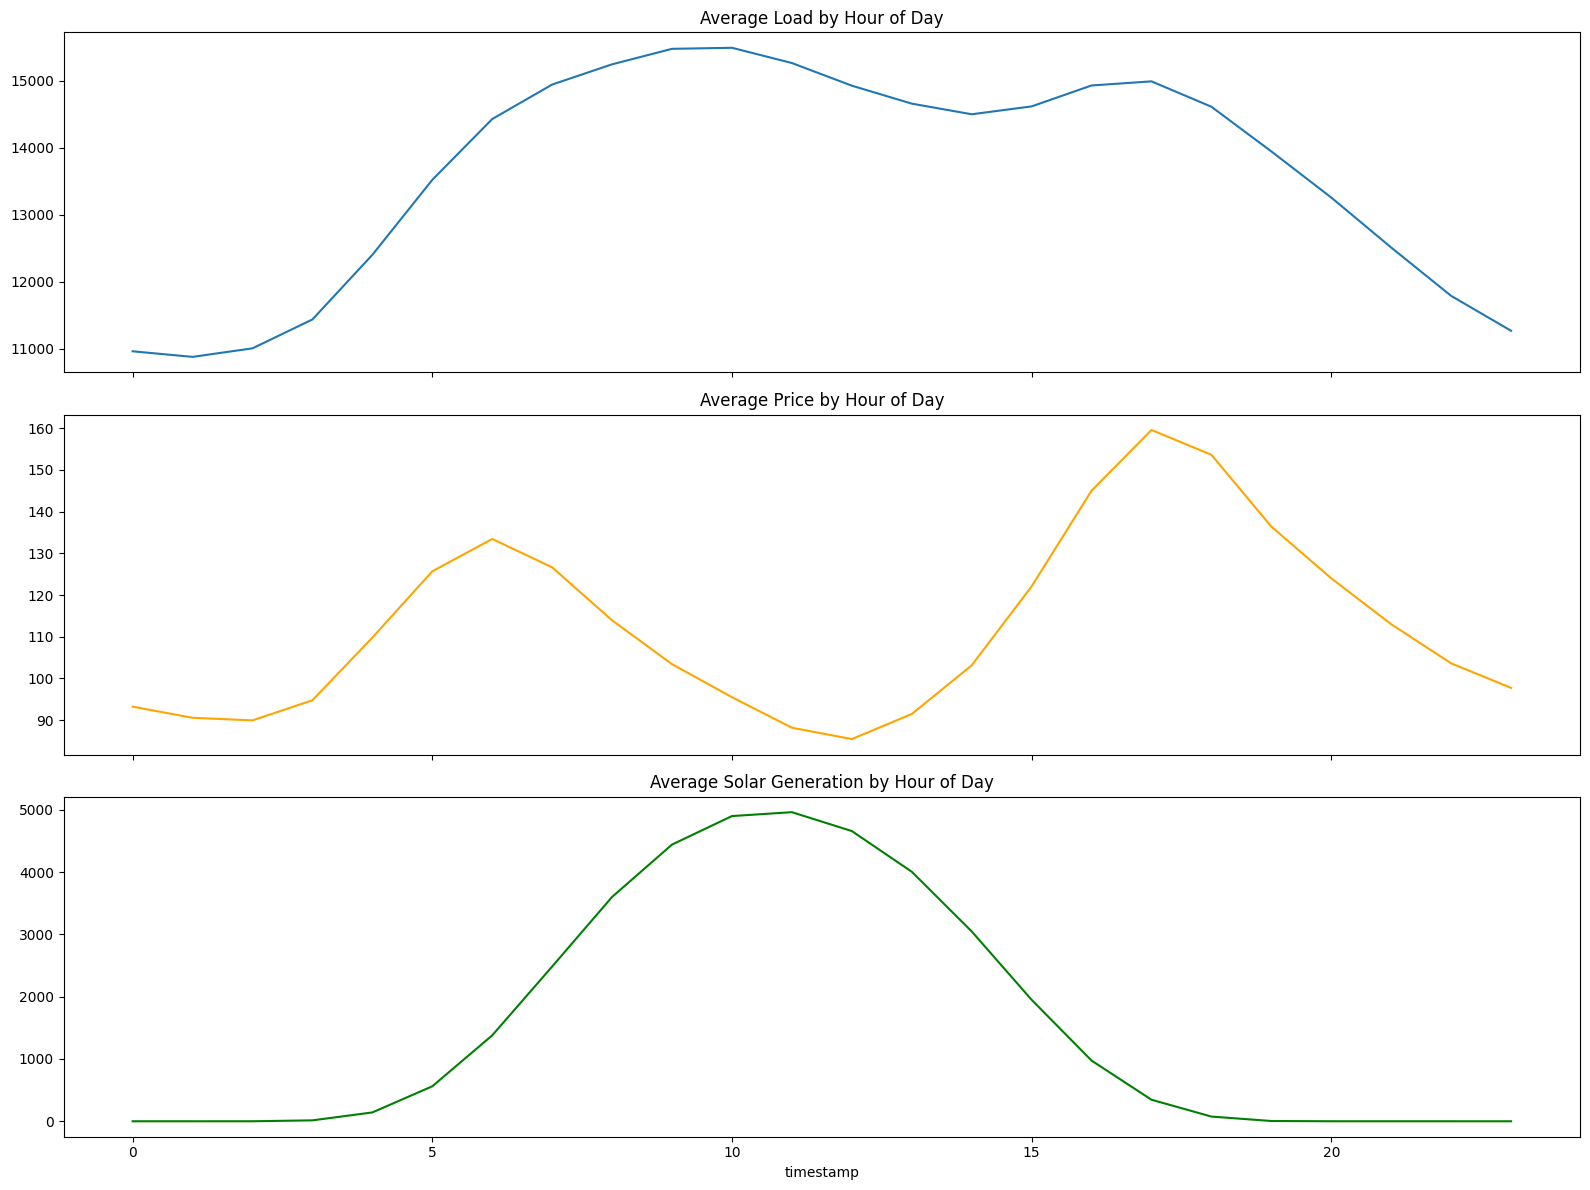

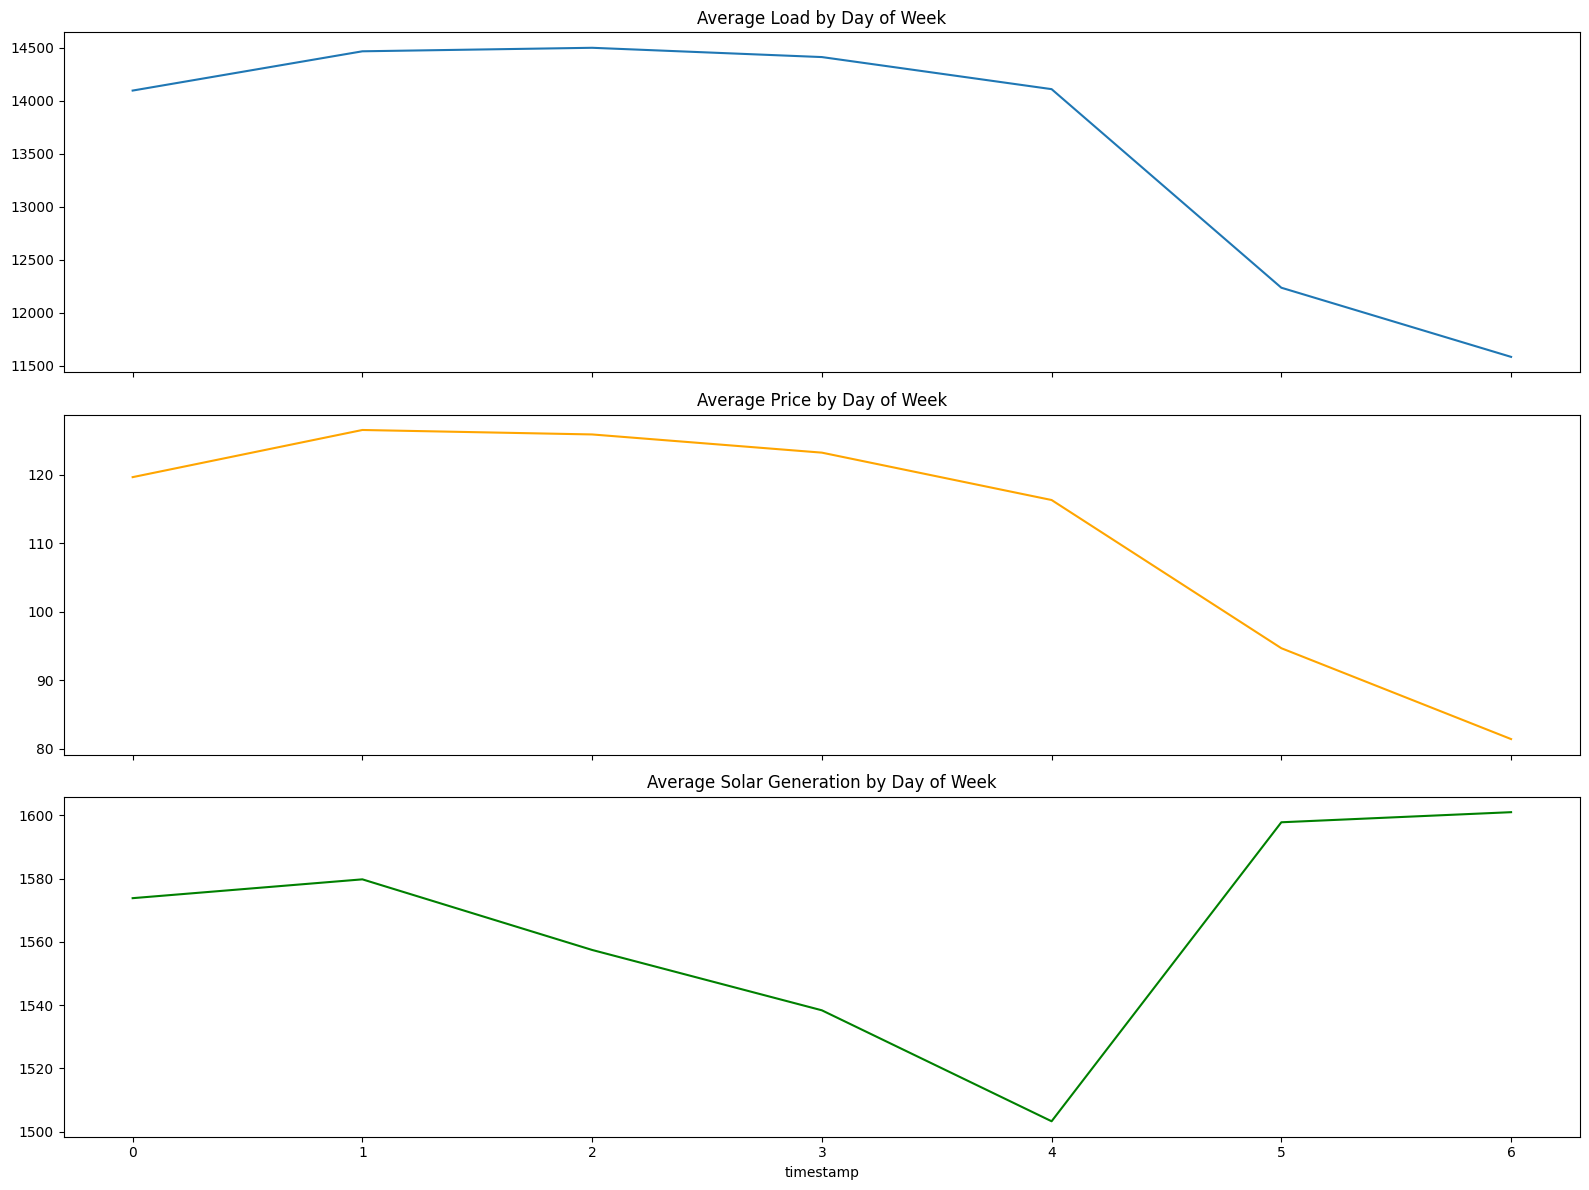

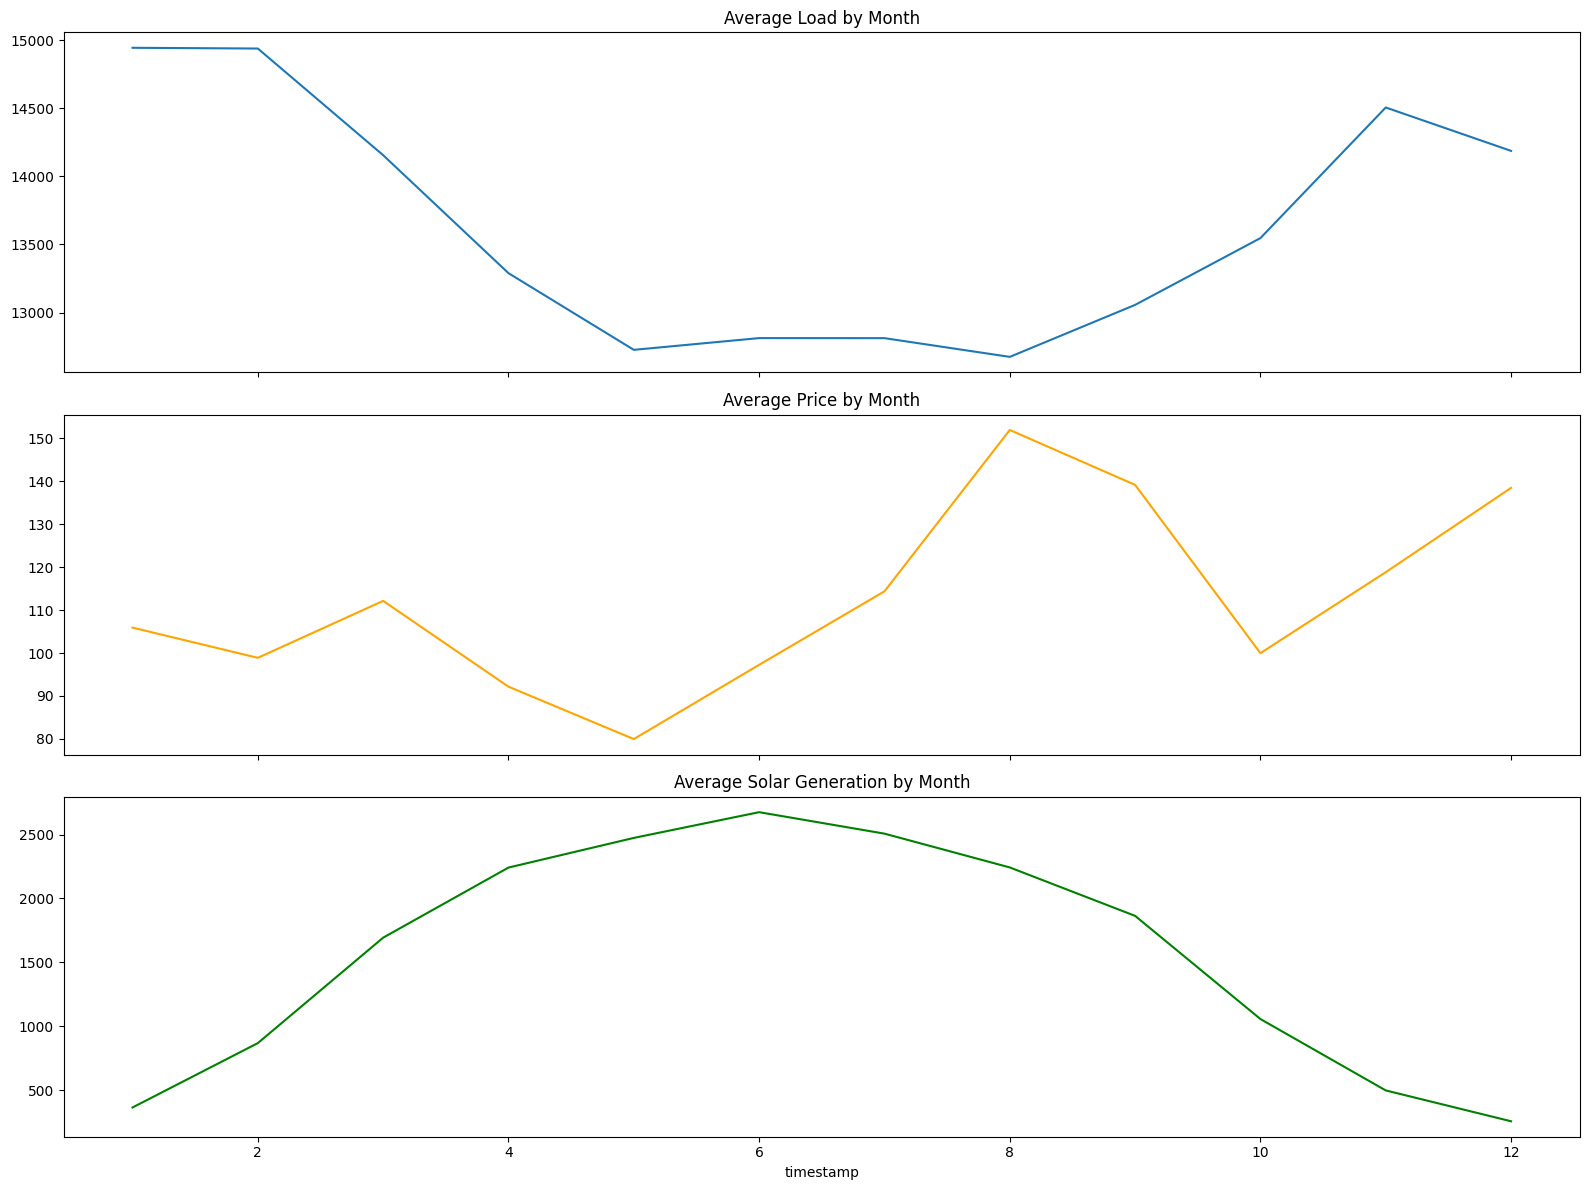

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
# Daily seasonality (hour of day)
df.groupby(df.index.hour)['cons_total_grid'].mean().plot(ax=axes[0], title='Average Load by Hour of Day')
df.groupby(df.index.hour)['price_de_lu'].mean().plot(ax=axes[1], title='Average Price by Hour of Day', color='orange')
df.groupby(df.index.hour)['gen_solar'].mean().plot(ax=axes[2], title='Average Solar Generation by Hour of Day', color='green')
plt.tight_layout()
plt.show()
# Weekly seasonality (day of week)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
df.groupby(df.index.dayofweek)['cons_total_grid'].mean().plot(ax=axes[0], title='Average Load by Day of Week')
df.groupby(df.index.dayofweek)['price_de_lu'].mean().plot(ax=axes[1], title='Average Price by Day of Week', color='orange')
df.groupby(df.index.dayofweek)['gen_solar'].mean().plot(ax=axes[2], title='Average Solar Generation by Day of Week', color='green')
plt.tight_layout()
plt.show()
# Yearly seasonality (month)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
df.groupby(df.index.month)['cons_total_grid'].mean().plot(ax=axes[0], title='Average Load by Month')
df.groupby(df.index.month)['price_de_lu'].mean().plot(ax=axes[1], title='Average Price by Month', color='orange')
df.groupby(df.index.month)['gen_solar'].mean().plot(ax=axes[2], title='Average Solar Generation by Month', color='green')
plt.tight_layout()
plt.show()

### 3. Correlation Analysis
We will examine the correlation between generation types, load, and price to identify key relationships and potential drivers.

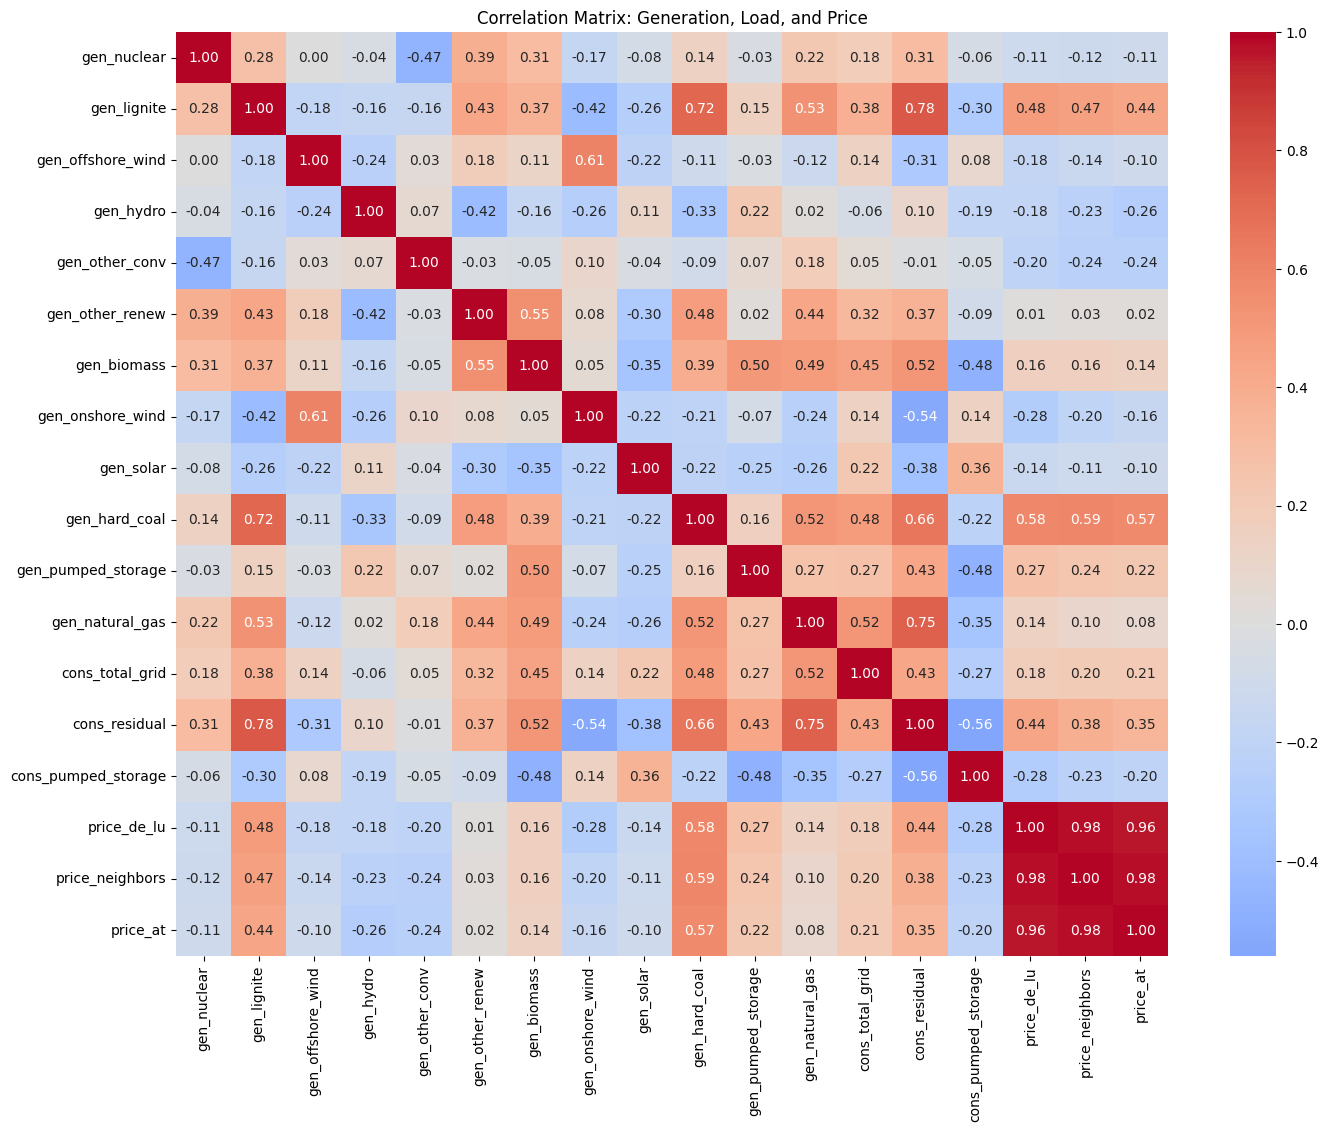

In [8]:
# Select relevant columns for correlation analysis
corr_cols = [col for col in df.columns if ('gen_' in col or 'cons_' in col or 'price' in col)]
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Generation, Load, and Price')
plt.show()

### 4. Outlier Detection (Price Spikes)
We will identify and visualize outliers in the price data, focusing on extreme spikes in the German power market.

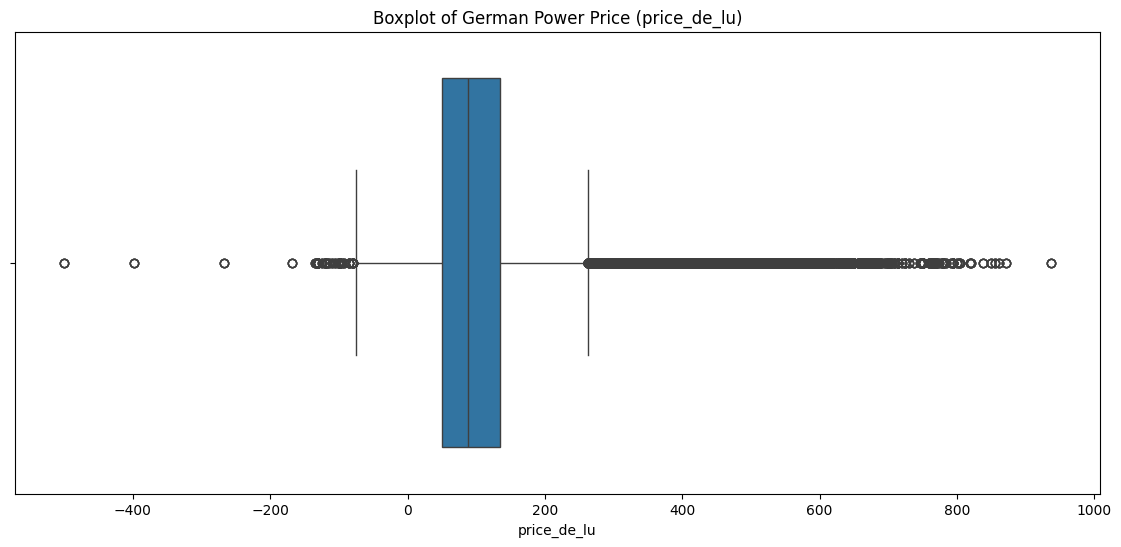

Number of price spikes above 99th percentile: 1752


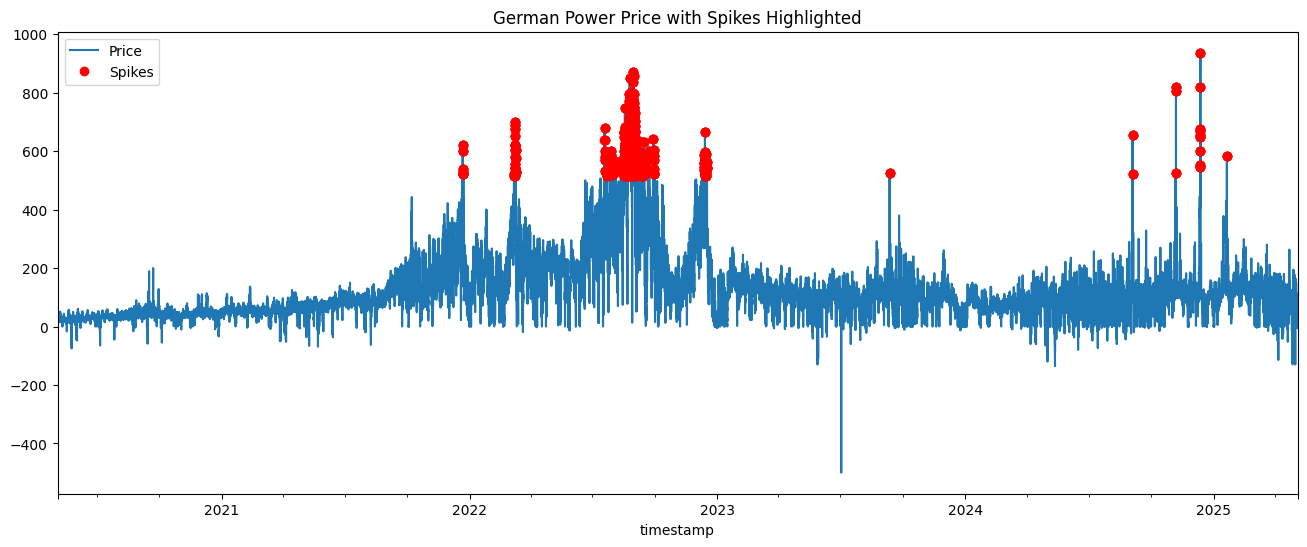

In [9]:
# Visualize price distribution and highlight outliers
plt.figure(figsize=(14, 6))
sns.boxplot(x=df['price_de_lu'])
plt.title('Boxplot of German Power Price (price_de_lu)')
plt.show()
# Identify extreme price spikes (e.g., beyond 99th percentile)
threshold = df['price_de_lu'].quantile(0.99)
spikes = df[df['price_de_lu'] > threshold]
print(f"Number of price spikes above 99th percentile: {len(spikes)}")
plt.figure(figsize=(16, 6))
df['price_de_lu'].plot(label='Price')
spikes['price_de_lu'].plot(style='o', color='red', label='Spikes')
plt.legend()
plt.title('German Power Price with Spikes Highlighted')
plt.show()

### 5. Renewable Penetration Trends Over Time
We will analyze how the share of renewable generation (wind, solar, hydro, biomass, etc.) has evolved over time.

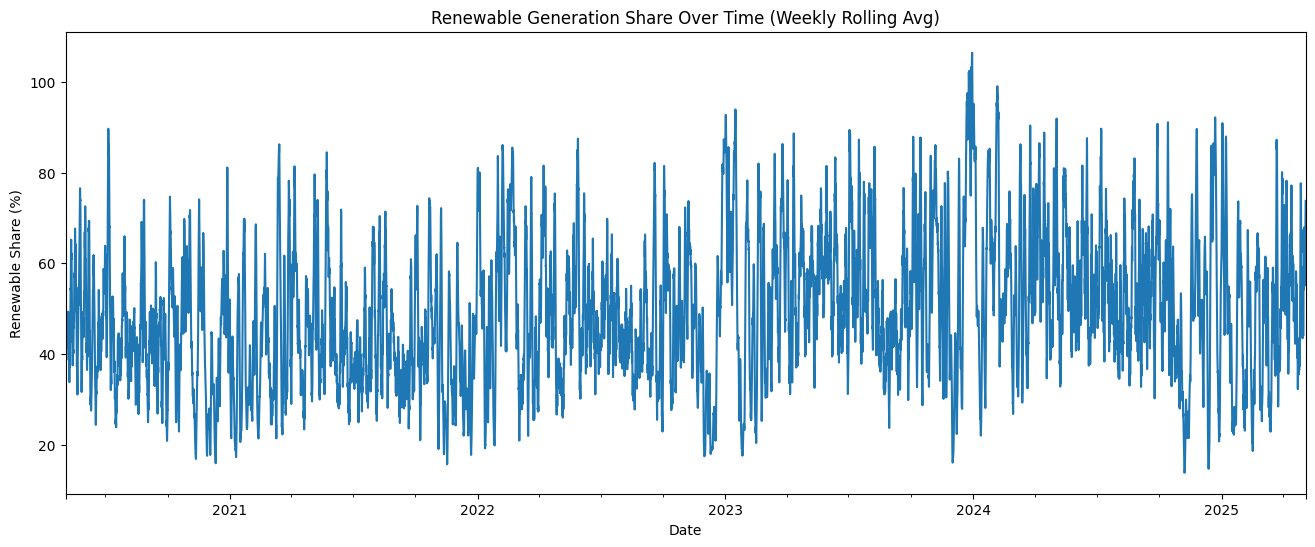

In [10]:
# Calculate renewable share over time
renewable_cols = ['gen_onshore_wind', 'gen_offshore_wind', 'gen_solar', 'gen_hydro', 'gen_biomass', 'gen_other_renew']
df['renewable_gen'] = df[renewable_cols].sum(axis=1)
df['renewable_share'] = df['renewable_gen'] / df['cons_total_grid'] * 100
plt.figure(figsize=(16, 6))
df['renewable_share'].rolling(24*7).mean().plot()  # 1-week rolling average
plt.title('Renewable Generation Share Over Time (Weekly Rolling Avg)')
plt.ylabel('Renewable Share (%)')
plt.xlabel('Date')
plt.show()

### 6. Relationship Between Forecasts (proj_*) and Actuals
We will compare forecasted values (proj_*) with actuals to assess forecast accuracy and identify systematic biases.

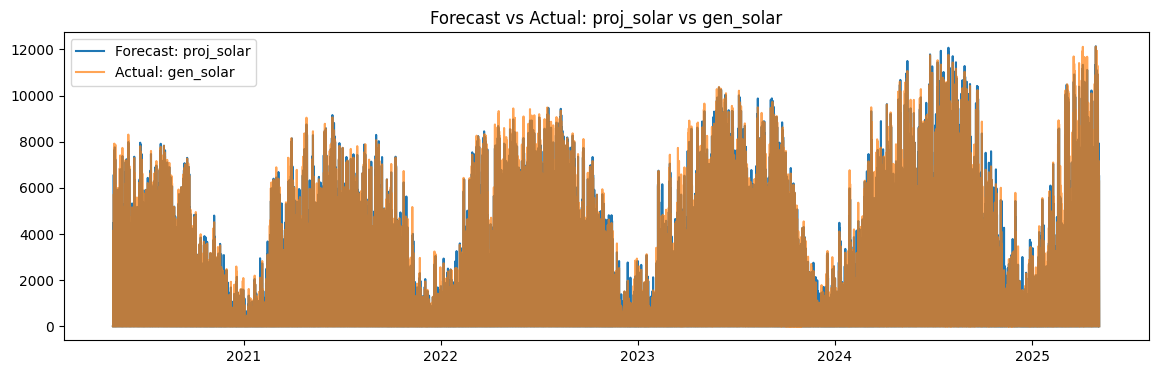

Mean Absolute Error for proj_solar vs gen_solar: 115.07


In [11]:
# Compare forecasts (proj_*) with actuals for wind and solar
import numpy as np
proj_cols = [col for col in df.columns if col.startswith('proj_')]
actual_cols = [col.replace('proj_', 'gen_') for col in proj_cols]
for proj, actual in zip(proj_cols, actual_cols):
    if actual in df.columns:
        plt.figure(figsize=(14, 4))
        plt.plot(df[proj], label=f'Forecast: {proj}')
        plt.plot(df[actual], label=f'Actual: {actual}', alpha=0.7)
        plt.title(f'Forecast vs Actual: {proj} vs {actual}')
        plt.legend()
        plt.show()
        mae = np.mean(np.abs(df[proj] - df[actual]))
        print(f'Mean Absolute Error for {proj} vs {actual}: {mae:.2f}')

### Additional EDA: Forecast Error Distribution Over Time
We will analyze the distribution and trends of forecast errors (proj_* vs gen_*) to identify periods of high/low accuracy and potential systematic biases.

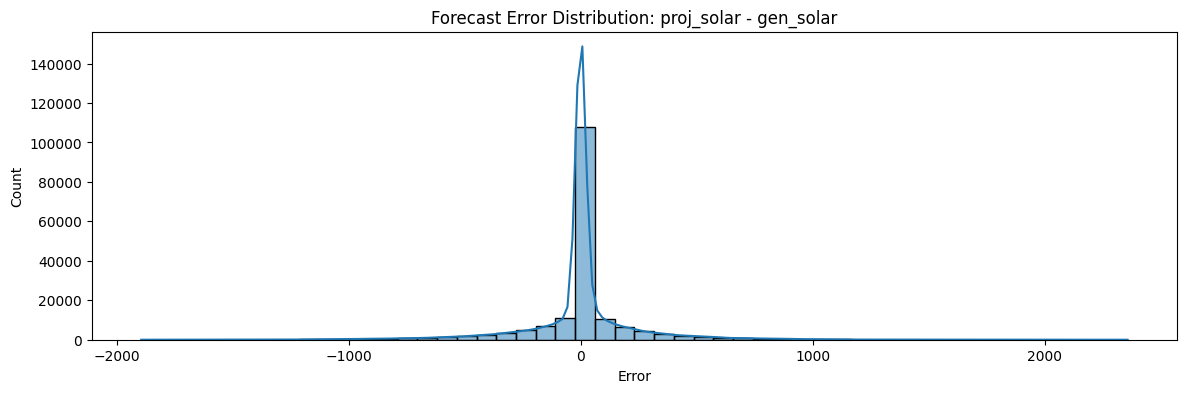

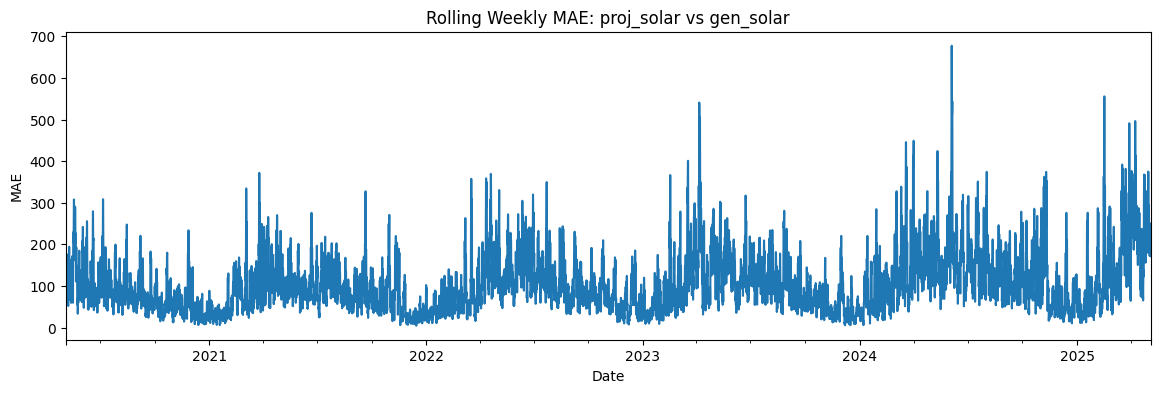

In [13]:
# Plot forecast error distribution and rolling MAE for each proj_*/gen_* pair
for proj in proj_cols:
    actual = proj.replace('proj_', 'gen_')
    if actual in df.columns:
        error = df[proj] - df[actual]
        plt.figure(figsize=(14, 4))
        sns.histplot(error.dropna(), bins=50, kde=True)
        plt.title(f'Forecast Error Distribution: {proj} - {actual}')
        plt.xlabel('Error')
        plt.show()
        # Rolling MAE
        rolling_mae = error.abs().rolling(24*7).mean()
        plt.figure(figsize=(14, 4))
        rolling_mae.plot()
        plt.title(f'Rolling Weekly MAE: {proj} vs {actual}')
        plt.ylabel('MAE')
        plt.xlabel('Date')
        plt.show()

### Additional EDA: Extreme Event Analysis
We will identify and summarize extreme events, such as negative prices and demand peaks, which are critical for risk management and operational planning.

In [14]:
# Identify negative price events
negative_prices = df[df['price_de_lu'] < 0]
print(f"Number of negative price events: {len(negative_prices)}")
if not negative_prices.empty:
    display(negative_prices[['price_de_lu']].head())
# Identify demand peaks (top 1%)
demand_threshold = df['cons_total_grid'].quantile(0.99)
demand_peaks = df[df['cons_total_grid'] > demand_threshold]
print(f"Number of demand peak events (top 1%): {len(demand_peaks)}")
if not demand_peaks.empty:
    display(demand_peaks[['cons_total_grid']].head())

Number of negative price events: 4928


,price_de_lu
timestamp,
2020-05-11 01:00:00+00:00,-0.01
2020-05-11 01:15:00+00:00,-0.01
2020-05-11 01:30:00+00:00,-0.01
2020-05-11 01:45:00+00:00,-0.01
2020-05-17 11:00:00+00:00,-5.19


Number of demand peak events (top 1%): 1754


,cons_total_grid
timestamp,
2020-11-19 10:15:00+00:00,18659.50
2020-11-19 10:30:00+00:00,18701.75
2020-11-19 10:45:00+00:00,18763.75
2020-11-19 11:00:00+00:00,18693.25
2020-11-19 11:15:00+00:00,18673.00


### Additional EDA: Data Quality & Anomaly Detection
We will check for duplicate timestamps and sudden jumps in key variables, which may indicate data quality issues or anomalies.

In [16]:
# Check for duplicate timestamps
duplicates = df.index.duplicated().sum()
print(f"Number of duplicate timestamps: {duplicates}")
# Check for sudden jumps in price and load (simple diff threshold)
price_jumps = (df['price_de_lu'].diff().abs() > df['price_de_lu'].std() * 5).sum()
load_jumps = (df['cons_total_grid'].diff().abs() > df['cons_total_grid'].std() * 5).sum()
print(f"Number of extreme price jumps: {price_jumps}")
print(f"Number of extreme load jumps: {load_jumps}")

Number of duplicate timestamps: 0
Number of extreme price jumps: 0
Number of extreme load jumps: 0


There are no duplicate timestamps and sudden jumps in price/load—important for ensuring reliable analysis and reporting

## Lead/Lag Analysis Between Forecasts and Actuals
We will explore whether forecast errors are autocorrelated or if there is a systematic lead/lag between forecasts and actuals.

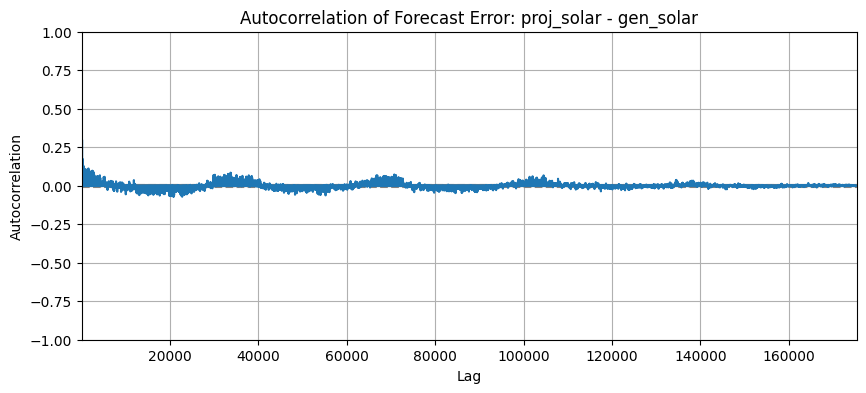

In [17]:
# Simple cross-correlation plot for each proj_*/gen_* pair
for proj in proj_cols:
    actual = proj.replace('proj_', 'gen_')
    if actual in df.columns:
        error = df[proj] - df[actual]
        plt.figure(figsize=(10, 4))
        pd.plotting.autocorrelation_plot(error.dropna())
        plt.title(f'Autocorrelation of Forecast Error: {proj} - {actual}')
        plt.show()

This is a Lead/lag analysis between forecasts and actuals, using autocorrelation plots of forecast errors. This helps identify if errors are persistent or if there’s a systematic lag—valuable for improving forecasting processes. 